# What happens when the vector of Attention reduced
> Reference Code : https://velog.io/@hjk1996/Transformer-from-scratch-Attention-is-all-you-need

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math

# Positional Encoding

In [2]:
class PositionalEncoding(nn.Module):
    def __init__(self, max_len, d_model):
        super().__init__()

        # p: [max_len, 1]
        p = torch.arange(0, max_len).unsqueeze(1)
        # i: [1, d_model/2]
        i = torch.arange(0, d_model, 2).unsqueeze(0)
        # divisor: [max_len, d_model/2] by broadcasting
        divisor = p / 10000 ** (i / d_model)

        pe = torch.zeros(max_len, d_model)
        # pe의 짝수 부분에 sin 정보 저장
        pe[:, 0::2] = torch.sin(divisor)
        # pe의 홀수 부분에 cos 정보 저장
        pe[:, 1::2] = torch.cos(divisor)
        # pe: [1, max_len, d_model]
        pe = pe.unsqueeze(0)
        # state_dict에 저장하지만 훈련시키지 않기 위해 buffer에 등록
        self.register_buffer('pe', pe)

    def forward(self, x):
        return x + self.pe

In [3]:
def ScaledDotProductAttention(Q, K, V, mask=None):
    dk = Q.size(-1)
    scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(dk)

    if mask is not None:
        scores = scores.masked_fill(mask==0, -1e9)

    attn = torch.softmax(scores, dim=-1)

    out = torch.matmul(attn, V)
    return out, attn

# Multi Head Attention

In [4]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model: int=512, num_heads: int=8):
        super().__init__()
        assert d_model % num_heads == 0, "d_model must be a multiple of num_heads"
        self.d_model = d_model
        self.num_heads = num_heads
        self.head_size = d_model // self.num_heads
        self.save_attn = False
        self.attn_name = None
        self.attn_store = None

        # query, key, value, output을 Linear 선형변환(가중치 연산을 하기 위함)
        self.w_q = nn.ModuleList([nn.Linear(self.head_size, self.head_size) for _ in range(self.num_heads)])
        self.w_k = nn.ModuleList([nn.Linear(self.head_size, self.head_size) for _ in range(self.num_heads)])
        self.w_v = nn.ModuleList([nn.Linear(self.head_size, self.head_size) for _ in range(self.num_heads)])
        self.w_o = nn.Linear(d_model, d_model)

    def forward(self, Q, K, V, mask=None):
        # query, key, value: [batch_size, max_len, d_model]

        bs, max_len, d_model = Q.shape
        
        # 선형변환된 Q, K, V를 8개의 헤드로 나눔
        # query, key, value: [batch_size, num_heads, max_len, d_model]
        Q = Q.view(bs, max_len, self.num_heads, self.head_size).transpose(1, 2)
        K = K.view(bs, max_len, self.num_heads, self.head_size).transpose(1, 2)
        V = V.view(bs, max_len, self.num_heads, self.head_size).transpose(1, 2)

        Q = torch.stack([self.w_q[i](Q[:, i]) for i in range(self.num_heads)], dim=1)
        K = torch.stack([self.w_k[i](K[:, i]) for i in range(self.num_heads)], dim=1)
        V = torch.stack([self.w_v[i](V[:, i]) for i in range(self.num_heads)], dim=1)

        # Scaled Dot Product Attention(Scaled: head_size(64)**0.5 → 8로 나눔)
        # scores: [batch_size, num_heads, max_len, max_len]
        scores = torch.matmul(Q, K.transpose(-2, -1)) / (self.head_size ** 0.5)

        # 패딩 토큰, Look Ahead 마스킹
        if mask is not None:
            # softmax에서 0을 출력시키기위해 최소값 부여
            scores = scores.masked_fill(mask==0, -1e9)

        # attention: [batch_size, num_heads, max_len, max_len]
        attention = F.softmax(scores, dim=-1)
        if self.save_attn and (self.attn_name is not None) and (self.attn_store is not None):
            self.attn_store[self.attn_name] = attention.detach().cpu()
        
        # out: [batch_size, num_heads, max_len, head_size] (max_len, max_len) @ (max_len, head_size)
        out = torch.matmul(attention, V)
        # 8개의 헤드를 하나로 합쳐 차원을 축소
        # out: [batch_size, max_len, d_model]
        out = out.transpose(1, 2).contiguous().view(bs, max_len, d_model)
        out = self.w_o(out)
        return out

### Q1. 선형변환을 하고 헤드를 나누면 그 특성(가중치)이 잘 유지될까?
- → 가중치 학습 전 먼저 8개의 헤드로 나누고 각 헤드마다 독립된 가중치를 학습시켜 보았다.

# Feed Forward Network

In [5]:
class FeedForwardNetwork(nn.Module):
    def __init__(self, d_model: int=512, ff_size: int=2048):
        super().__init__()
        self.linear1 = nn.Linear(d_model, ff_size)
        self.linear2 = nn.Linear(ff_size, d_model)

    def forward(self, x):
        x = self.linear1(x)
        x = F.relu(x)
        x = self.linear2(x)
        return x

# Encoder Layer

In [6]:
class EncoderLayer(nn.Module):
    def __init__(self, d_model: int=512, num_heads: int=8, ff_size: int=2048, dropout: float=0.1):
        super().__init__()
        # MultiHeadAttention 객체 생성
        self.attention = MultiHeadAttention(d_model, num_heads)
        # Layer Normalization: 배치 1개의 토큰마다 모든 feature들(=d_model) 정규화
        self.norm1 = nn.LayerNorm(d_model)
        self.dropout1 = nn.Dropout(dropout)
        self.ff = FeedForwardNetwork(d_model, ff_size)
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout2 = nn.Dropout(dropout)

    def forward(self, x, mask=None):
        # x: [batch_size, max_len, d_model]

        # out: [batch_size, max_len, d_model], 입력: (Q, K, V, mask)
        out = self.attention(x, x, x, mask)
        # skip connection(잔차 연결): x를 그대로 LayerNorm한 결과에 더함
        out = self.norm1(x + self.dropout1(out))
        # out: [batch_size, max_len, d_model]
        out = self.ff(out)
        # skip connection(잔차 연결): out를 그대로 Feed Forward한 결과에 더함
        out = self.norm2(out + self.dropout2(out))
        return out

# Encoder

# vocab_size란?
- 단어사전, 모델에서 최대로 표현할 수 있는 토큰의 종류(pad, unk 포함)
- Embedding을 통해 원핫벡터 or 토큰 ID를 d_model 벡터로 바꾼다.
    - 입력 데이터가 원핫벡터이면 [batch_size, seq_len, vocab_size] → [batch_size, seq_len, d_model]
    - 입력 데이터가 토큰 ID이면 [batch_size, seq_len] → [batch_size, seq_len, d_model]
- Tokenizer랑 같이 묶어서 사용한다.

In [7]:
class Encoder(nn.Module):
    def __init__(self, vocab_size, max_len, num_encs, d_model, num_heads, ff_size, dropout):
        super().__init__()
        # Input Embedding
        self.input_embedding = nn.Embedding(vocab_size, d_model)
        # Positional Encoding
        self.pos_encoding = PositionalEncoding(max_len, d_model)
        # Encoder를 6겹으로 쌓는다.
        self.enc_layers = nn.ModuleList([EncoderLayer(d_model, num_heads, ff_size, dropout) for _ in range(num_encs)])
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, mask=None):
        # 입력 데이터는 원핫벡터 or 토큰 ID 단어 시퀀스 데이터
        # x: [batch_size, max_len, vocab_size] → [batch_size, max_len, d_model]
        x = self.input_embedding(x)
        x = self.pos_encoding(x)
        x = self.dropout(x)
        # encoding 반복
        for enc_layer in self.enc_layers:
            x = enc_layer(x, mask)
        # x: [batch_size, max_len, d_model]
        return x

# Decoder Layer

# Casual Attention
- Decoder는 Encoder의 출력을 해석해 다음 시퀀스를 생성하는 역할을 한다.
- 따라서 현재 스텝보다 미래에 있는 토큰을 참조하는 것은 반칙이므로 이것을 방지할 필요가 있다.
- Decoder 입력 데이터에 Mask를 적용해 미래 토큰을 참조하지 못하게 한다.
    - Mask는 하삼각행렬로 이루어져 있다.
# Cross Attention
- Encoder의 출력을 참고하여 Decoder Layer에 Multi Head Attention을 적용한다.
- Decoder 중간 단계에서 Q는 Decoder Layer의 출력을 사용하고 K, V는 Encoder의 출력을 사용한다. 
- Encoder와 마찬가지로 Padding Mask를 사용한다.

In [8]:
class DecoderLayer(nn.Module):
    def __init__(self, d_model: int=512, num_heads: int=8, ff_size: int=2048, dropout: float=0.1):
        super().__init__()
        # 첫 번째 Multi Head Attention
        self.self_attention = MultiHeadAttention(d_model, num_heads)
        self.norm1 = nn.LayerNorm(d_model)
        # 두 번째 Cross Multi Head Attention
        self.cross_attention = MultiHeadAttention(d_model, num_heads)
        self.norm2 = nn.LayerNorm(d_model)
        # 세 번째 Feed Forward Layer
        self.ff = FeedForwardNetwork(d_model, ff_size)
        self.norm3 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, enc_out, enc_mask=None, dec_mask=None):
        # 첫 번째 Multi Head Attention에 Look-Ahead Mask 적용
        self_attn = self.self_attention(x, x, x, dec_mask)
        x = self.norm1(x + self.dropout(self_attn))

        # 두 번째 Cross Multi Head Attention에 Decoder Layer 출력(Q), Encoder 출력(K, V), Padding Mask 적용
        cross_attn = self.cross_attention(x, enc_out, enc_out, enc_mask)
        x = self.norm2(x + self.dropout(cross_attn))

        # 세 번째 Feed Forward Layer 적용
        ffo = self.ff(x)
        x = self.norm3(x + self.dropout(ffo))
        return x

# Decoder

In [9]:
class Decoder(nn.Module):
    def __init__(self, vocab_size, max_len, num_decs, d_model, num_heads, ff_size, dropout):
        super().__init__()
        # Out Embedding
        self.out_embbeding = nn.Embedding(vocab_size, d_model)
        # Positional Encoding
        self.pos_encoding = PositionalEncoding(max_len, d_model)
        # Decoder를 6겹으로 쌓는다.
        self.dec_layers = nn.ModuleList([DecoderLayer(d_model, num_heads, ff_size, dropout) for _ in range(num_decs)])
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, enc_out, enc_mask=None, dec_mask=None):
        # 입력 데이터는 원핫벡터 or 토큰 ID 단어 시퀀스 데이터
        # x: [batch_size, max_len, vocab_size] → [batch_size, max_len, d_model]
        x = self.out_embbeding(x)
        x = self.pos_encoding(x)
        x = self.dropout(x)
        # decoding 반복
        for dec in self.dec_layers:
            x = dec(x, enc_out, enc_mask, dec_mask)
        # x: [batch_size, max_len, d_model]
        return x

# Transformer

# src_vocab_size
- 인코더 입력(Source), [batch_size, src_len]
- 모델이 참고할 입력 문장(원문)
- 패딩 마스크만 필요
# trg_vocab_size
- 디코더 입력(Target), [batch_size, trg_len]
- 모델이 만들어야할 출력 문장(번역문/정답)
- &lt;bos&gt;부터 시작하는 trg_input과
- &lt;eos&gt;로 끝나는 trg_y로 나뉨
- 패딩 마스크와 룩어헤드 마스크 둘 다 필요

In [10]:
class Transformer(nn.Module):
    def __init__(self, src_vocab_size: int, trg_vocab_size: int, pad_token_idx: int, max_len: int, num_encs: int, num_decs: int, d_model: int, num_heads: int, ff_size: int, dropout: float):
        super().__init__()
        self.encoder = Encoder(src_vocab_size, max_len, num_encs, d_model, num_heads, ff_size, dropout)
        self.decoder = Decoder(trg_vocab_size, max_len, num_decs, d_model, num_heads, ff_size, dropout)
        # 다음 단어를 출력하기 위해 최종 출력인 d_model 벡터를 trg_vocab_size로 선형변환해 분류한다.
        self.out_linear = nn.Linear(d_model, trg_vocab_size)
        self.pad_token_idx = pad_token_idx

    def create_masks(self, src, trg):
        # 입력 데이터가 [batch_size, max_len]일 때, 값을 저장
        batch_size, max_len = src.shape
        # src 행렬에서 self.pad_token_idx(보통 0)이 아닌 것들을 T로 변환시킴
        # scores 행렬은 [batch_size, num_heads, max_len(Q_len), max_len(K_len)]이므로 Key 차원만 마스킹하면 된다.
        # enc_mask: [batch_size, 1, 1, max_len]
        enc_mask = (src != self.pad_token_idx).unsqueeze(1).unsqueeze(2)
        # trg 행렬에서 self.pad_token_idx(보통 0)이 아닌 것들을 T로 변환시킴
        # scores 행렬 [batch_size, num_heads, max_len(Q_len), max_len(K_len)]에서 Query 차원을 마스킹하기 위함이다.
        # Look Ahead Mask와 합치기 쉽게 마지막 차원을 1로 둔다.
        # dec_pad_mask: [batch_size, 1, max_len, 1]
        dec_pad_mask = (trg != self.pad_token_idx).unsqueeze(1).unsqueeze(3)
        # look_ahead_mask: [max_len, max_len]
        look_ahead_mask = torch.tril(torch.ones(max_len, max_len, device=src.device)).bool()
        # dec_mask: [batch_size, 1, max_len, max_len]
        dec_mask = dec_pad_mask & look_ahead_mask
        return enc_mask, dec_mask

    def forward(self, enc_input, dec_input):
        enc_mask, dec_mask = self.create_masks(enc_input, dec_input)
        enc_out = self.encoder(enc_input, enc_mask)
        dec_out = self.decoder(dec_input, enc_out, enc_mask, dec_mask)
        out = self.out_linear(dec_out)
        return out

In [11]:
import numpy as np
import random
import os
import torch
import torch.nn as nn
import torch.optim as optim
import time
from torch.utils.data import DataLoader, Dataset
from sklearn.model_selection import train_test_split
from copy import deepcopy

In [12]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(device)

seed = 42
random.seed(seed)
os.environ['PYTHONMASHSEED'] = str(seed)
np.random.seed(seed)

torch.manual_seed(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
torch.backends.cudnn.enabled = False

if device == 'cuda':
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

cuda


# Prepare Dataset

In [13]:
class DelayedCopyDataset(Dataset):
    def __init__(self, num_samples=10000, seq_len=10, delay=10, pad_token=10):
        self.num_samples = num_samples
        self.seq_len = seq_len
        self.delay = delay
        self.vocab_size = seq_len
        self.pad_token = pad_token

    def __len__(self):
        return self.num_samples

    def __getitem__(self, idx):
        seq = torch.randint(0, self.vocab_size, (self.seq_len,))
        x = torch.cat([seq, torch.full((self.delay,), self.pad_token)])
        y = torch.cat([torch.full((self.delay,), self.pad_token), seq])
        return x, y

dataset = DelayedCopyDataset(num_samples=10000, seq_len=100, delay=20, pad_token=100)
for i in range(3):
    x, y = dataset[i]
    print(x)
    print(y)

tensor([ 42,  67,  76,  14,  26,  35,  20,  24,  50,  13,  78,  14,  10,  54,
         31,  72,  15,  95,  67,   6,  49,  76,  73,  11,  99,  13,  41,  69,
         87,  19,  72,  80,  75,  29,  33,  64,  39,  76,  32,  10,  86,  22,
         77,  19,   7,  23,  43,  94,  93,  77,  70,   9,  70,  39,  86,  99,
         15,  84,  78,   8,  66,  30,  40,  60,  70,  61,  23,  20,  11,  61,
         77,  89,  84,  53,  48,   9,  83,   7,  58,  91,  14,  91,  36,   3,
         82,  90,  89,  28,  55,  33,  27,  47,  65,  89,  41,  45,  61,  39,
         61,  64, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100,
        100, 100, 100, 100, 100, 100, 100, 100])
tensor([100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100,
        100, 100, 100, 100, 100, 100,  42,  67,  76,  14,  26,  35,  20,  24,
         50,  13,  78,  14,  10,  54,  31,  72,  15,  95,  67,   6,  49,  76,
         73,  11,  99,  13,  41,  69,  87,  19,  72,  80,  75,  29,  33,  64,
         39,  7

In [14]:
train_list, val_list = train_test_split(dataset, test_size=0.2, random_state=seed)
print(len(train_list), len(val_list))

train_batches = DataLoader(dataset=train_list, batch_size=64, shuffle=True)
val_batches = DataLoader(dataset=val_list, batch_size=64, shuffle=False)

8000 2000


# Define Train Functions

In [15]:
PAD = dataset.pad_token

model = Transformer(src_vocab_size=121, trg_vocab_size=121, pad_token_idx=PAD, max_len=120, num_encs=6, num_decs=6, d_model=512, num_heads=8, ff_size=2048, dropout=0.1)
criterion = nn.CrossEntropyLoss(ignore_index=PAD)
# 학습률이 너무 크면 발산하여 학습이 깨지고, 반대로 학습률이 너무 작아도 학습이 되지 않는다.
optimizer = optim.Adam(model.parameters(), lr=1e-4, betas=(0.9, 0.98), eps=1e-9)

In [16]:
def token_accuracy(logits, targets, pad_id=None):
    # 예상 단어(디코더 Vocab)에 대해 가장 확률이 높은 값을 반환합니다.
    # preds: [bs, max_len, vocab_size] → [bs, max_len]
    preds = logits.argmax(dim=-1)
    
    # padding 토큰이 없을 때 수행
    if pad_id is None:
        return (preds == targets).float().mean().item()

    # padding 토큰은 False를 반환하여 mask에 저장
    mask = (targets != pad_id)
    # 전체 토큰이 다 False면(다 Padding이면) 0을 반환
    if mask.sum().item() == 0:
        return 0.0
    # preds에서 targets와 맞는 값을 True로 반환합니다.
    correct = (preds == targets) & mask
    return (correct.float().sum() / mask.float().sum()).item()

In [17]:
def noam_lr(step, d_model, warmup_steps):
    return (d_model ** -0.5) * min(step ** -0.5, step * (warmup_steps ** -1.5))

scheduler = optim.lr_scheduler.LambdaLR(optimizer=optimizer, lr_lambda=lambda step: noam_lr(step+1, 512, 200))

In [18]:
def attach_attn_names_and_store(model):
    store = {}
    
    for li, layer in enumerate(model.encoder.enc_layers):
        layer.attention.attn_name = f"enc.L{li:02d}.self"
        layer.attention.attn_store = store

    for li, layer in enumerate(model.decoder.dec_layers):
        layer.self_attention.attn_name = f"dec.L{li:02d}.self"
        layer.self_attention.attn_store = store
        layer.cross_attention.attn_name = f"dec.L{li:02d}.cross"
        layer.cross_attention.attn_store = store

    return store

In [19]:
@torch.no_grad()
def evaluate(model, criterion, valid_loader, device, pad_id=None):
    model.eval()
    
    attn_store = attach_attn_names_and_store(model)
    for m in model.modules():
        if isinstance(m, MultiHeadAttention):
            m.save_attn = True
    
    total_loss = 0.0
    total_acc = 0.0
    n_batches = 0

    for x, y in valid_loader:
        x = x.to(device)
        y = y.to(device)

        logits = model(x, y)
        vocab_size = logits.size(-1)

        # logits: [bs*max_len, vocab_size], y : [bs*max_len]
        loss = criterion(logits.reshape(-1, vocab_size), y.reshape(-1))
        acc = token_accuracy(logits, y, pad_id=pad_id)

        total_loss += loss.item()
        total_acc += acc
        n_batches += 1

    return total_loss / max(n_batches, 1), total_acc / max(n_batches, 1), attn_store

In [20]:
def train_model(model, criterion, optimizer, epochs, train_loader, valid_loader, device, pad_id=None, grad_clip=1.0, early_stop_patience=None):
    model.to(device)

    attn_store = {}
    best_val_loss = float("inf")
    best_state = None
    patience_left = early_stop_patience

    for epoch in range(1, epochs+1):
        model.train()
        total_loss = 0.0
        total_acc = 0.0
        n_batches = 0
        start = time.time()

        for x, y in train_loader:
            x = x.to(device)
            y = y.to(device)

            optimizer.zero_grad(set_to_none=True)

            logits = model(x, y)
            vocab_size = logits.size(-1)

            loss = criterion(logits.reshape(-1, vocab_size), y.reshape(-1))
            loss.backward()
            
            # 기울기 폭발 방지
            if grad_clip is not None:
                torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)

            optimizer.step()
            scheduler.step()

            acc = token_accuracy(logits.detach(), y, pad_id=pad_id)

            total_loss += loss
            total_acc += acc
            n_batches += 1

        train_loss = total_loss / max(n_batches, 1)
        train_acc = total_acc / max(n_batches, 1)

        val_loss, val_acc, attn_store = evaluate(model, criterion, valid_loader, device, pad_id=pad_id)

        elapsed_time = time.time() - start
        print(f'[Epoch {epoch}/{epochs}]: {elapsed_time:.3f} sec, train loss: {train_loss:.4f}, train acc: {train_acc * 100:.3f}% / valid loss: {val_loss:.4f}, valid_acc: {val_acc * 100:.3f}%')

        if early_stop_patience is not None:
            if val_loss < best_val_loss - 1e-6:
                best_val_loss = val_loss
                best_state = deepcopy(model.state_dict())
            else:
                patience_left -= 1
                if patience_left <= 0:
                    print("Early Stopped")
                    break
    
    if best_state is not None:
        model.load_state_dict(best_state)

    return model, attn_store

# Training

In [21]:
model, attn_store = train_model(model, criterion, optimizer, 30, train_loader=train_batches, valid_loader=val_batches, device=device, pad_id=PAD, grad_clip=1.0, early_stop_patience=None)

[Epoch 1/30]: 37.445 sec, train loss: 4.9368, train acc: 0.932% / valid loss: 4.8564, valid_acc: 1.637%
[Epoch 2/30]: 42.529 sec, train loss: 4.7512, train acc: 2.475% / valid loss: 4.6058, valid_acc: 5.299%
[Epoch 3/30]: 41.946 sec, train loss: 4.5639, train acc: 5.070% / valid loss: 4.4435, valid_acc: 9.926%
[Epoch 4/30]: 41.871 sec, train loss: 4.4362, train acc: 8.100% / valid loss: 4.3065, valid_acc: 14.309%
[Epoch 5/30]: 41.868 sec, train loss: 4.3221, train acc: 11.570% / valid loss: 4.1774, valid_acc: 19.365%
[Epoch 6/30]: 41.867 sec, train loss: 4.2164, train acc: 15.293% / valid loss: 4.0567, valid_acc: 24.745%
[Epoch 7/30]: 41.937 sec, train loss: 4.1172, train acc: 19.213% / valid loss: 3.9447, valid_acc: 30.188%
[Epoch 8/30]: 41.983 sec, train loss: 4.0240, train acc: 23.252% / valid loss: 3.8397, valid_acc: 35.364%
[Epoch 9/30]: 42.087 sec, train loss: 3.9371, train acc: 27.398% / valid loss: 3.7406, valid_acc: 40.136%
[Epoch 10/30]: 41.880 sec, train loss: 3.8534, train 

In [38]:
torch.save(attn_store, "var_attn_store_epoch30.pt")

# Visualization

In [77]:
import matplotlib.pyplot as plt

base_attn_store = torch.load("attention_store_AIAYN\\base_attn_store_epoch30.pt", map_location="cpu")
var_attn_store = torch.load("attention_store_AIAYN\\var_attn_store_epoch30.pt", map_location="cpu")

def visual_models_heads(base_attn_store, var_attn_store, title, module, b=0, heads=None, percentile=99.5):
    A = base_attn_store[module]
    V = var_attn_store[module]
    
    B, H, Tq, Tk = A.shape
    if heads is None:
        heads = list(range(H))
    
    matsA, matsV = [], []
    for h in heads:
        matsA.append(A[b, h, :, :].detach().float().cpu().numpy())
        matsV.append(V[b, h, :, :].detach().float().cpu().numpy())
    
        vmax = np.percentile(np.concatenate([m.reshape(-1) for m in matsA + matsV]), percentile)
    
    fig, axes = plt.subplots(2, len(heads), figsize=(3*len(heads), 6), squeeze=False)
    fig.subplots_adjust(hspace=0.5)

    for j, h in enumerate(heads):
        im0 = axes[0, j].imshow(matsA[j], aspect="auto", vmin=0.0, vmax=vmax)
        axes[0, j].set_title(f"base h{h}")
        axes[0, 0].set_xlabel("key")
        axes[0, 0].set_ylabel("query")

        im1 = axes[1, j].imshow(matsV[j], aspect="auto", vmin=0.0, vmax=vmax)
        axes[1, j].set_title(f"var h{h}")
        axes[1, 0].set_xlabel("key")
        axes[1, 0].set_ylabel("query")

    fig.suptitle(title, fontsize=16, y=1.0)
    fig.colorbar(im0, ax=axes.ravel().tolist(), fraction=0.02, pad=0.02)
    plt.show()

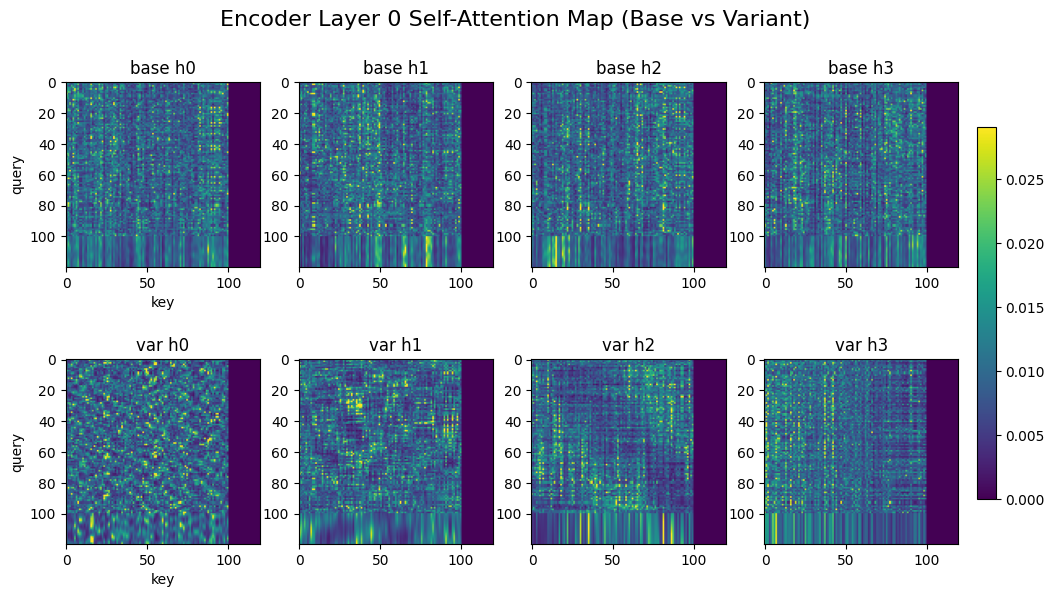

In [84]:
visual_models_heads(base_attn_store, var_attn_store, "Encoder Layer 0 Self-Attention Map (Base vs Variant)", "enc.L00.self", b=0, heads=[0, 1, 2, 3], percentile=99.5)

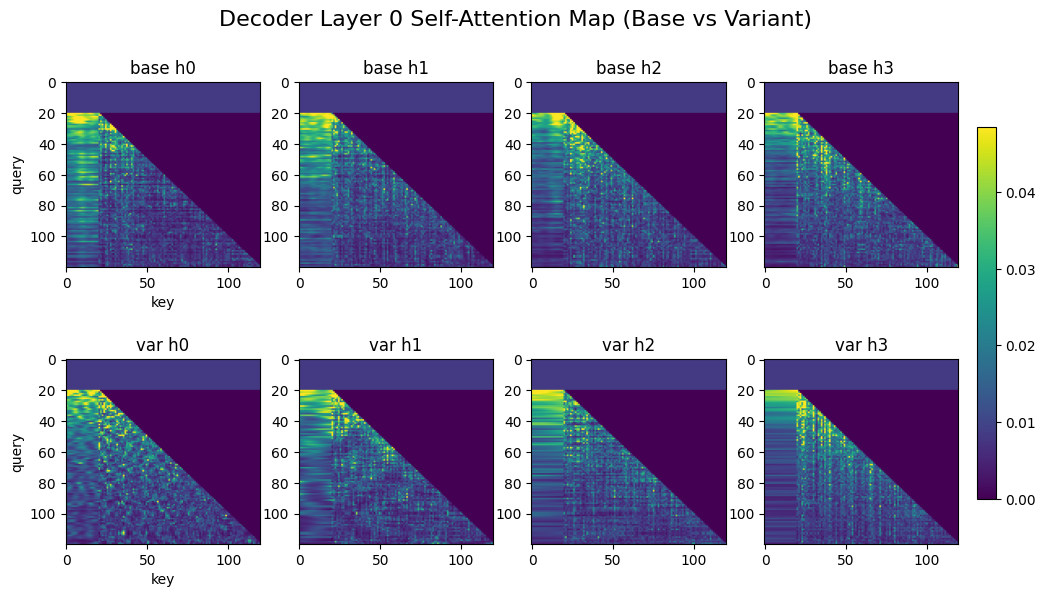

In [85]:
visual_models_heads(base_attn_store, var_attn_store, "Decoder Layer 0 Self-Attention Map (Base vs Variant)", "dec.L00.self", b=0, heads=[0, 1, 2, 3], percentile=99.5)

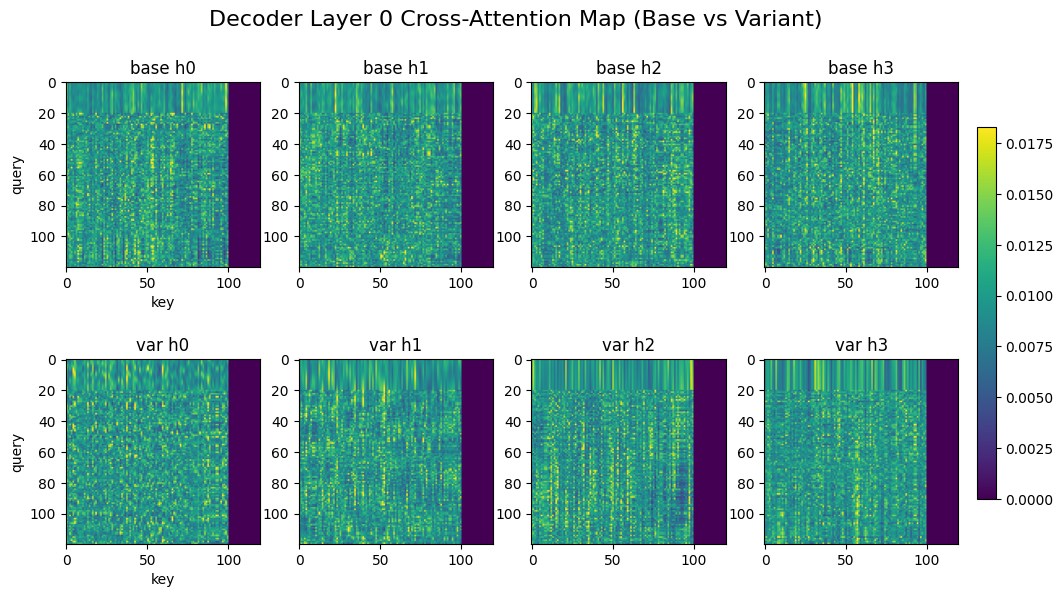

In [86]:
visual_models_heads(base_attn_store, var_attn_store, "Decoder Layer 0 Cross-Attention Map (Base vs Variant)", "dec.L00.cross", b=0, heads=[0, 1, 2, 3], percentile=99.5)